In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("C:/Users/Unicom-7344/Desktop/Emiliano_Palacios/Uni 2/Aprendizaje Automatico/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [21]:
df = df[['Pclass', 'Sex', 'Age', 'Fare', 'Survived']]
df['Age'] = df['Age'].fillna(df['Age'].mean())

df['Fare'] = df['Fare'].fillna(df['Fare'].mean())
df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})


df.head()

,Pclass,Sex,Age,Fare,Survived
0,3,NaN,22.0,7.2500,0
1,1,NaN,38.0,71.2833,1
2,3,NaN,26.0,7.9250,1
3,1,NaN,35.0,53.1000,1
4,3,NaN,35.0,8.0500,0


In [4]:
X = df[['Pclass', 'Sex', 'Age', 'Fare']]

y = df['Survived']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [7]:
svm = SVC(kernel='linear')

In [8]:
svm.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [9]:
y_pred_svm = svm.predict(X_test)

In [10]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print(f"Accuracy del modelo SVM: {svm_accuracy:.2%}")

Accuracy del modelo SVM: 78.21%


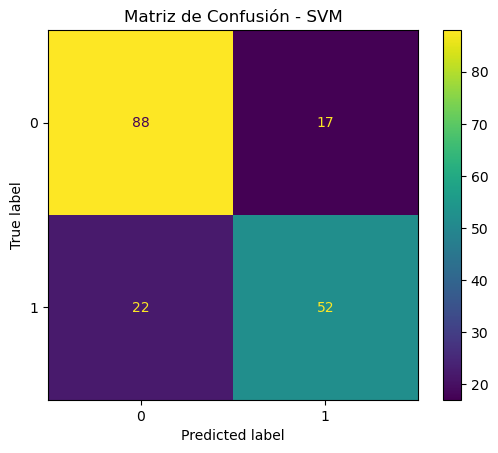

In [11]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm
)

plt.title("Matriz de Confusión - SVM")

plt.show()

In [12]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       105
           1       0.75      0.70      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [13]:
sgd = SGDClassifier(random_state=42)

In [14]:
sgd.fit(X_train, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [15]:
y_pred_sgd = sgd.predict(X_test)

In [16]:
sgd_accuracy = accuracy_score(y_test, y_pred_sgd)

print(f"Accuracy del modelo SGD: {sgd_accuracy:.2%}")

Accuracy del modelo SGD: 77.65%


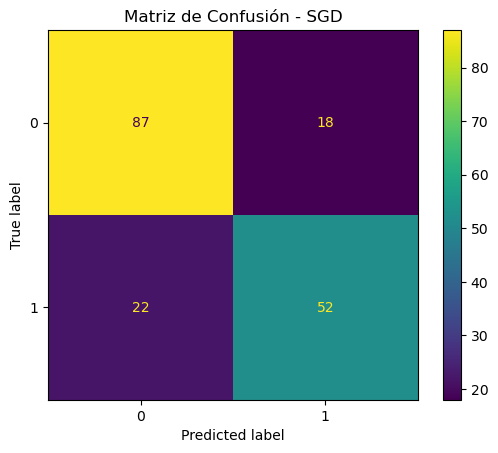

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_sgd
)

plt.title("Matriz de Confusión - SGD")

plt.show()

In [18]:
print(classification_report(y_test, y_pred_sgd))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81       105
           1       0.74      0.70      0.72        74

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [19]:
resultados = pd.DataFrame({
    'Modelo': ['SVM', 'SGD'],
    'Accuracy': [svm_accuracy, sgd_accuracy]
})

resultados

,Modelo,Accuracy
0,SVM,0.782123
1,SGD,0.776536
